In [ ]:
import pandas as pd
tips = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
tips


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


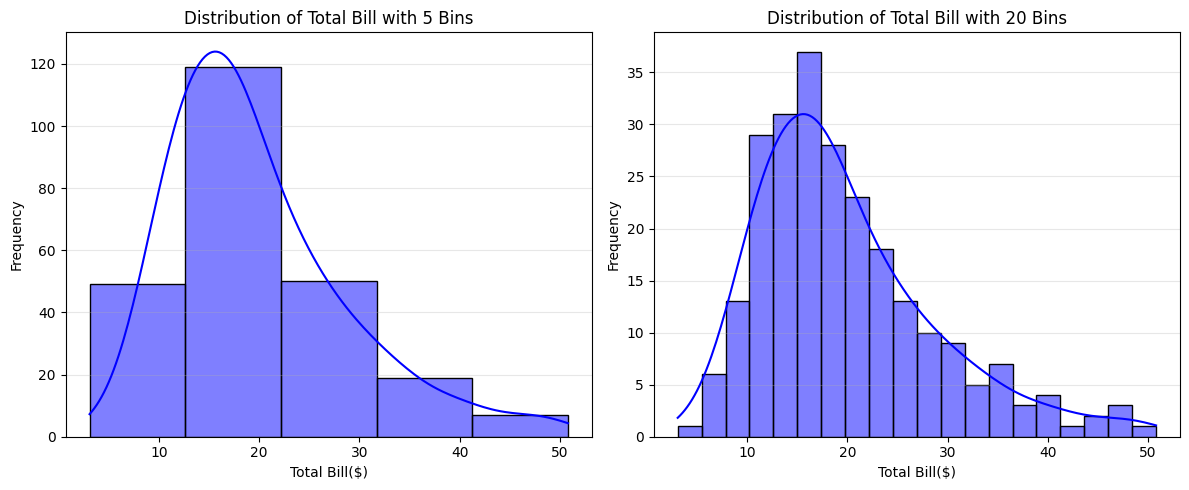

In [ ]:
#Task 1: Distribution Analysis Using Histograms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

tips = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
#Histogram of Total Bill with 5 bins
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
sns.histplot(tips['total_bill'],bins=5,kde=True,color='blue')
plt.xlabel('Total Bill($)')
plt.ylabel('Frequency')
plt.title("Distribution of Total Bill with 5 Bins")
plt.grid(axis='y', alpha=0.3)


#Histogram of Total Bill with 20 bins
#plt.figure(figsize=(12,5))
plt.subplot(1,2,2)
sns.histplot(tips['total_bill'],bins=20,kde=True,color='blue')
plt.xlabel('Total Bill($)')
plt.ylabel('Frequency')
plt.title("Distribution of Total Bill with 20 Bins")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
print("Q1:What does the distribution of total_bill look like — is it symmetric, left-skewed, or right-skewed?\n")
print("Ans : It is Right skewed which has long tail on right side which is also called as positive skewed\n")
print("Q2:How does changing the number of bins affect your ability to interpret the distribution?")
print("Changing the number of bins affects our ability to see the data with More granular detail and spread of values more clearly")


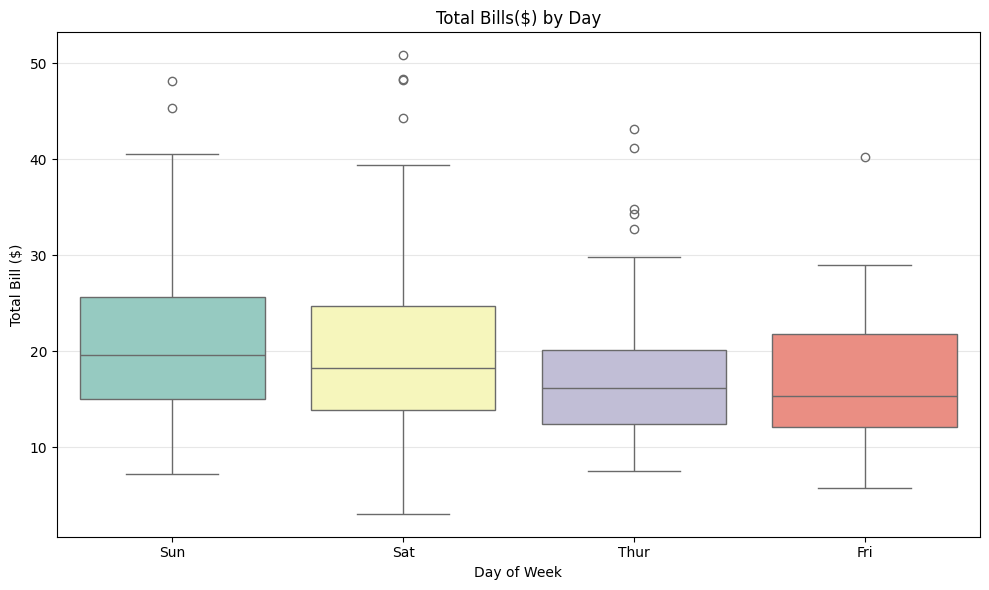

Average Bill by day:
day
Sun     19.63
Sat     18.24
Thur    16.20
Fri     15.38
Name: total_bill, dtype: float64


In [ ]:
#Task 2: Outlier Detection Using Box Plots
#Create side-by-side box plots comparing the distribution of total_bill across the four days (day column: Thur, Fri, Sat, Sun).
plt.figure(figsize=(10,6))
tips = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv")
sns.boxplot(data=tips, x='day', y='total_bill', hue='day', palette='Set3')
plt.xlabel('Day of Week')
plt.ylabel('Total Bill ($)')
plt.title('Total Bills($) by Day')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()
print("Average Bill by day:")
print(tips.groupby('day')['total_bill'].median().sort_values(ascending=False))



In [ ]:
#Questions:
#1.On which day does the median total bill appear highest?
#ANS: Sunday is having highest median


In [ ]:
#Q2:Identify at least one day that appears to have outliers. Calculate the IQR for that day manually using df.groupby() and quantile(), and verify whether the points you identified qualify as outliers using the standard rule: Q1 − 1.5×IQR and Q3 + 1.5×IQR.
print("saterday that have highest value outliers 44,48,51")
sat = tips[tips['day'] == 'Sat']

Q1 = sat['total_bill'].quantile(0.25)
Q3 = sat['total_bill'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, lower_bound, upper_bound
print(f"lower bound{lower_bound}")
print(f"Upper Bound bound {upper_bound}")
outliers = sat[(sat['total_bill'] < lower_bound) |
               (sat['total_bill'] > upper_bound)]
#print(outliers)
print(outliers['total_bill'])
print("So the outliers that we identified are 48,44,51 are matching the calculated outliers")






saterday that have highest value outliers 44,48,51
lower bound-2.3475
Upper Bound bound 40.99250000000001
59     48.27
102    44.30
170    50.81
212    48.33
Name: total_bill, dtype: float64
So the outliers that we identified are 48,44,51 are matching the calculated outliers


In [ ]:
#Task 3: Multi-Variable Comparison Using an Interactive Plot
fig = px.scatter(tips, x='total_bill', y='tip',
                 color='time',
                 title='Petal Length vs Petal Width by Species',
                 labels={'total_bill': 'Total Bill($)',
                         'tip': 'tip'},
                 width=900, height=600)

fig.update_traces(marker=dict(size=10, opacity=0.7))
fig.show()

In [ ]:
print("Does there appear to be a relationship between total_bill and tip? Describe what you observe.")
print("Ans:Approximately most of them are giving the tip 20 to 25% of total bill so if total bill increase tip increases")
print("Do Lunch and Dinner transactions differ noticeably in their tipping patterns? What does the color separation reveal?")
print("Ans:The color separation helps to understand how the tips are given at lunch and dinner times.Here comparitilvely Dinner time tips are having more percentage of total bill than lunch time")
print("Identify one specific data point (visible via hover) that you find interesting or unusual, and briefly explain why")
print("Ans:There is a datapoint total_bill is 7.25 and tip is 5.15 which is almost 75% tip of total bill which is unsual")
